# Locally Weighted Regression 

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## 1. Choosing Features
For a housing-price-vs-size type problem, a straight line $\theta_0 + \theta_1 x_1$ may not fit the curve of the data well, as price grows quickly then levels off with size.

We can instead fit a polynomial in $x$ by treating powers of $x$ as new features:

$$\theta_0 + \theta_1 x_1$$

$$\theta_0 + \theta_1 x_1 + \theta_2 x_2^2$$

or, to avoid the curve blowing up again at large $x$, use a concave feature like $\sqrt{x}$ instead of $x^2$:

$$\theta_0 + \theta_1 x_1 + \theta_2 \sqrt{x_2}$$

More generally we can mix several transformed features:

$$\theta_0 + \theta_1 x_1 + \theta_2 \sqrt{x_2} + \theta_3 \log(x_3)$$

**Key idea:** the model is still *linear in the parameters* $\theta$, even though it is a non-linear function of the original input $x$, this is what lets us keep using ordinary linear regression machinery (normal equations / gradient descent) after simply redefining the feature vector.


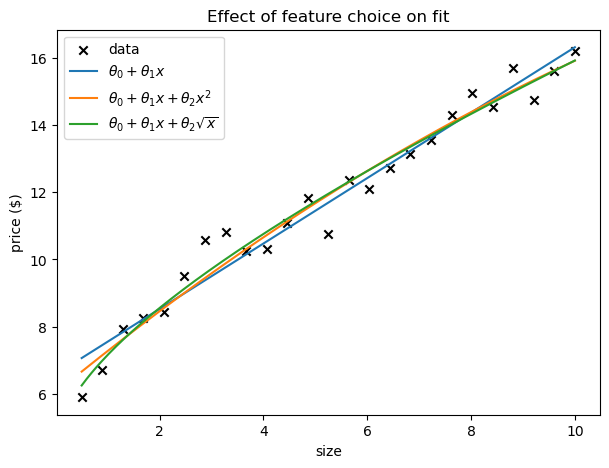

In [3]:
rng = np.random.default_rng(0)
x = np.linspace(0.5, 10, 25)
y = 3 + 4*np.sqrt(x) + rng.normal(0, 0.6, size=x.shape)  # "true" underlying trend

def fit(X, y):
    theta, *_ = np.linalg.lstsq(X, y, rcond=None)
    return theta

xg = np.linspace(0.5, 10, 200)

# straight line: theta0 + theta1*x
X1 = np.column_stack([np.ones_like(x), x])
t1 = fit(X1, y)
y1 = t1[0] + t1[1]*xg

# quadratic: theta0 + theta1*x + theta2*x^2
X2 = np.column_stack([np.ones_like(x), x, x**2])
t2 = fit(X2, y)
y2 = t2[0] + t2[1]*xg + t2[2]*xg**2

# sqrt feature: theta0 + theta1*x + theta2*sqrt(x)
X3 = np.column_stack([np.ones_like(x), x, np.sqrt(x)])
t3 = fit(X3, y)
y3 = t3[0] + t3[1]*xg + t3[2]*np.sqrt(xg)

plt.figure(figsize=(7,5))
plt.scatter(x, y, color='k', marker='x', label='data')
plt.plot(xg, y1, label=r'$\theta_0+\theta_1 x$')
plt.plot(xg, y2, label=r'$\theta_0+\theta_1 x+\theta_2 x^2$')
plt.plot(xg, y3, label=r'$\theta_0+\theta_1 x+\theta_2 \sqrt{x}$')
plt.xlabel('size'); plt.ylabel('price ($)')
plt.legend(); plt.title('Effect of feature choice on fit')
plt.show()


## 2. Parametric vs. Non-parametric Learning Algorithms

**Parametric learning algorithm**
- Has a **fixed** set of parameters $(\theta_i)$ to fit to the data.
- Ordinary linear regression is parametric: once trained, $\theta$ is fixed size no matter how much data you have.

**Non-parametric learning algorithm**
- The amount of "stuff" you need to keep grows (linearly) with the size of the data.
- **Locally weighted regression** is the classic example.


## 3. Locally Weighted Regression 

Ordinary linear regression: fit a single global $\theta$ to minimize

$$\frac{1}{2m}\sum_{i=1}^m \left(y^{(i)} - \theta^T x^{(i)}\right)^2, $$

Locally weighted regressioninstead, to evaluate the hypothesis at a *specific* query point $x$:

1. Find the data local to $x$.
2. Fit $\theta$ to minimize a weighted cost:

$$\sum_{i=1}^m w^{(i)} \left(y^{(i)} - \theta^T x^{(i)}\right)^2$$

where $w^{(i)}$ is a weight function — a Gaussian bell curve centered at the query point $x$:

$$w^{(i)} = \exp\left(-\frac{\left(x^{(i)} - x\right)^2}{2\tau^2}\right)$$

- If $|x^{(i)} - x|$ is **small**, $w^{(i)} \approx 1$ (point counts a lot).
- If $|x^{(i)} - x|$ is **large**, $w^{(i)} \approx 0$ (point barely counts).

Note: the weights are *not* a probability distribution — they don't need to (and don't) sum to 1; they're just a bump that happens to look Gaussian.

$\tau$ = the **bandwidth** parameter, controls how narrow/wide the bump is (how quickly the weight of a point falls off with distance).

LWR is useful for low-dimensional data sets that don't have too many features, since you must redo the weighted fit for every query point $x$).


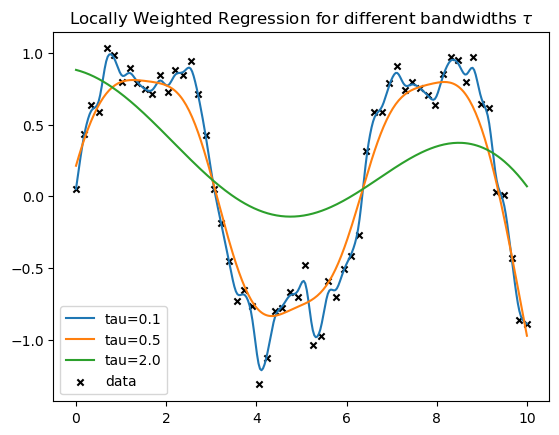

In [4]:
def gaussian_weights(x_query, X_train, tau):
    return np.exp(-((X_train - x_query) ** 2) / (2 * tau ** 2))

def locally_weighted_predict(x_query, X_train, y_train, tau):
    W = np.diag(gaussian_weights(x_query, X_train, tau))
    Xb = np.column_stack([np.ones_like(X_train), X_train])
    xq = np.array([1.0, x_query])
    theta = np.linalg.pinv(Xb.T @ W @ Xb) @ (Xb.T @ W @ y_train)
    return xq @ theta

# Wiggly synthetic data 
rng = np.random.default_rng(1)
Xtr = np.linspace(0, 10, 60)
ytr = np.sin(Xtr) + 0.3*np.sin(3*Xtr) + rng.normal(0, 0.15, size=Xtr.shape)

xg = np.linspace(0, 10, 300)
for tau in [0.1, 0.5, 2.0]:
    yhat = [locally_weighted_predict(xq, Xtr, ytr, tau) for xq in xg]
    plt.plot(xg, yhat, label=f'tau={tau}')

plt.scatter(Xtr, ytr, color='k', marker='x', s=20, label='data')
plt.legend(); plt.title('Locally Weighted Regression for different bandwidths $\\tau$')
plt.show()
